## get data

### car data

In [1]:
import urllib.request
url = "https://figshare.com/ndownloader/files/33524447"
urllib.request.urlretrieve(url, "FCD.csv")

('FCD.csv', <http.client.HTTPMessage at 0x7bd81aba8710>)

In [2]:
import os
os.listdir()

['.config', 'FCD.csv', 'sample_data']

In [3]:
import pandas as pd
df_fcd = pd.read_csv("FCD.csv")
df_fcd.head()

,cid,type,time,lon,lat,spd,turn,dis,roadid
0,b62b0f461be5ee9702131b83ac8a1abb,2,2020-09-01 10:23:50,118.762569,30.943402,3.127881,Unknown,297.148700,4724_4664
1,b62b0f461be5ee9702131b83ac8a1abb,2,2020-09-01 10:24:00,118.762527,30.943123,3.127881,Unknown,265.869890,4724_4664
2,b62b0f461be5ee9702131b83ac8a1abb,2,2020-09-01 10:24:10,118.762484,30.942844,3.127881,Unknown,234.591079,4724_4664
3,b62b0f461be5ee9702131b83ac8a1abb,2,2020-09-01 10:24:20,118.762442,30.942565,3.127881,Unknown,203.312269,4724_4664
4,b62b0f461be5ee9702131b83ac8a1abb,2,2020-09-01 10:24:30,118.762399,30.942286,3.127881,Unknown,172.033458,4724_4664


urllib.request.urlretrieve("https://figshare.com/ndownloader/files/33524711", "/tmp/myxxxx.csv")
dbutils.fs.mv("file:/tmp/myxxxx.csv", "dbfs:/EV_chargingMap/Xuancheng/road_info.csv")
display(dbutils.fs.ls("dbfs:/EV_chargingMap/Xuancheng/"))

In [7]:
url1 = "https://figshare.com/ndownloader/files/33524711"
urllib.request.urlretrieve(url1, "road_info.csv")

('road_info.csv', <http.client.HTTPMessage at 0x7bd7c53da350>)

In [8]:
df_road = pd.read_csv("road_info.csv")
df_road.head()

,cid,nlane,turn,dnroad,geom,len
0,4393_4423,3,S#U#L,4423_4471#4423_4393#4423_4448,LINESTRING(118.723892282 30.9160036330001;118....,612.797776
1,4393_9052,0,L#S#U#R,9052_8367#9052_9051#9052_4393#9052_9135,LINESTRING(118.723892282 30.9160036330001;118....,1066.484653
2,4423_4471,4,R#S#U#L,4471_4440#4471_4493#4471_4423#4471_4496,LINESTRING(118.728375699 30.9199501530001;118....,662.195967
3,4438_4439,0,S#U,4439_4448#4439_4438,LINESTRING(118.718755032 30.9211743930001;118....,462.097261
4,4438_4474,2,R#S#U#L,4474_4448#4474_4582#4474_4438#4474_4502,LINESTRING(118.718755032 30.9211743930001;118....,411.547206


## process data

In [4]:
df_fcd['time'] = pd.to_datetime(df_fcd['time'])

grouped_by_car = df_fcd.groupby('cid')

# Show the number of records per car
car_counts = grouped_by_car.size().reset_index(name='count')
display(car_counts.head())

# Access data for a specific car
example_cid = df_fcd['cid'].iloc[0]  # get a sample cid
df_single_car = grouped_by_car.get_group(example_cid)
display(df_single_car.head())

,cid,count
0,00a2b0bdbf45e8aeb6ce8725313de453,54206
1,01677d8d689689b199d94933f5a0444c,43452
2,02896f23bf40753e4e4a76957d291d2e,57219
3,03b8e66e14f8706a742a2b9e431a8334,52819
4,05b94b63c3f11a0fc0113fa90872749a,60794


,cid,type,time,lon,lat,spd,turn,dis,roadid
0,b62b0f461be5ee9702131b83ac8a1abb,2,2020-09-01 10:23:50,118.762569,30.943402,3.127881,Unknown,297.148700,4724_4664
1,b62b0f461be5ee9702131b83ac8a1abb,2,2020-09-01 10:24:00,118.762527,30.943123,3.127881,Unknown,265.869890,4724_4664
2,b62b0f461be5ee9702131b83ac8a1abb,2,2020-09-01 10:24:10,118.762484,30.942844,3.127881,Unknown,234.591079,4724_4664
3,b62b0f461be5ee9702131b83ac8a1abb,2,2020-09-01 10:24:20,118.762442,30.942565,3.127881,Unknown,203.312269,4724_4664
4,b62b0f461be5ee9702131b83ac8a1abb,2,2020-09-01 10:24:30,118.762399,30.942286,3.127881,Unknown,172.033458,4724_4664


In [10]:
df_fcd['time'] = pd.to_datetime(df_fcd['time'])

df_sep1 = df_fcd[df_fcd['time'].dt.date == pd.to_datetime('2020-09-01').date()]

df_sep1_sorted = df_sep1.sort_values(by=['cid', 'time'])

grouped_sep1 = df_sep1_sorted.groupby('cid')

print(f"Number of active cars on 2020-09-01: {len(grouped_sep1)}")

# view one group
sample_cid = df_sep1_sorted['cid'].iloc[0]
sample_df = grouped_sep1.get_group(sample_cid)
display(sample_df[['time', 'roadid', 'lon', 'lat']])

Number of active cars on 2020-09-01: 498


,time,roadid,lon,lat
69847,2020-09-01 06:27:40,4808_4893,118.747294,30.946646
69854,2020-09-01 06:27:50,4808_4893,118.747130,30.947042
69860,2020-09-01 06:28:00,4808_4893,118.746965,30.947438
69866,2020-09-01 06:28:10,4808_4893,118.746801,30.947834
69874,2020-09-01 06:28:20,4808_4893,118.746637,30.948230
...,...,...,...,...
517492,2020-09-01 23:57:30,5082_5123,118.743479,30.961297
517496,2020-09-01 23:57:40,5082_5123,118.743481,30.961792
517498,2020-09-01 23:57:50,5082_5123,118.743483,30.962288
517503,2020-09-01 23:58:00,5082_5123,118.743485,30.962783


In [13]:
car_ids = list(grouped_sep1.groups.keys())

# Check for redundancy (e.g., duplicates)
print("\nChecking for duplicates...")
unique_cids = set(car_ids)

if len(car_ids) == len(unique_cids):
    print("✅ No duplicate car IDs found.")
else:
    print("⚠️ Duplicate car IDs detected!")
    from collections import Counter
    duplicates = [item for item, count in Counter(car_ids).items() if count > 1]
    print("Duplicated IDs:", duplicates)


Checking for duplicates...
✅ No duplicate car IDs found.


## shortest path

In [14]:
import networkx as nx

# Build the road network graph
G = nx.DiGraph()

for _, row in df_road.iterrows():
    try:
        src, dst = row['cid'].split('_')
        G.add_edge(src, dst, weight=row['len'], roadid=row['cid'])
    except Exception as e:
        print(f"Skipping row with cid={row['cid']}: {e}")

In [15]:
car_shortest_paths = {}

for cid, group in grouped_sep1:
    road_sequence = group['roadid'].tolist()

    if len(road_sequence) < 2:
        continue  # not enough data

    # Extract start and end nodes
    try:
        start_road = road_sequence[0]
        end_road = road_sequence[-1]

        start_node = start_road.split('_')[0]
        end_node = end_road.split('_')[-1]

        # Compute shortest path using Dijkstra
        path_nodes = nx.dijkstra_path(G, start_node, end_node, weight='weight')
        path_length = nx.dijkstra_path_length(G, start_node, end_node, weight='weight')

        car_shortest_paths[cid] = {
            'start_node': start_node,
            'end_node': end_node,
            'path_nodes': path_nodes,
            'path_length': path_length
        }

    except (nx.NetworkXNoPath, nx.NodeNotFound) as e:
        car_shortest_paths[cid] = {
            'start_node': start_node,
            'end_node': end_node,
            'path_nodes': [],
            'path_length': None,
            'error': str(e)
        }

In [16]:
df_paths = pd.DataFrame.from_dict(car_shortest_paths, orient='index')
df_paths.reset_index(inplace=True)
df_paths.rename(columns={'index': 'cid'}, inplace=True)

display(df_paths.head())

,cid,start_node,end_node,path_nodes,path_length
0,00a2b0bdbf45e8aeb6ce8725313de453,4808,5123,"[4808, 4893, 4907, 4950, 5021, 5082, 5123]",1944.263510
1,01677d8d689689b199d94933f5a0444c,9163,4694,"[9163, 5010, 4907, 4893, 4808, 4694]",1582.047784
2,02896f23bf40753e4e4a76957d291d2e,5105,9042,"[5105, 8348, 5055, 4920, 4855, 4819, 4689, 466...",9434.437797
3,03b8e66e14f8706a742a2b9e431a8334,4832,4944,"[4832, 8365, 4917, 5005, 4991, 4904, 4973, 496...",3579.704291
4,05b94b63c3f11a0fc0113fa90872749a,4634,4758,"[4634, 4732, 4745, 4758]",1821.755611


## display

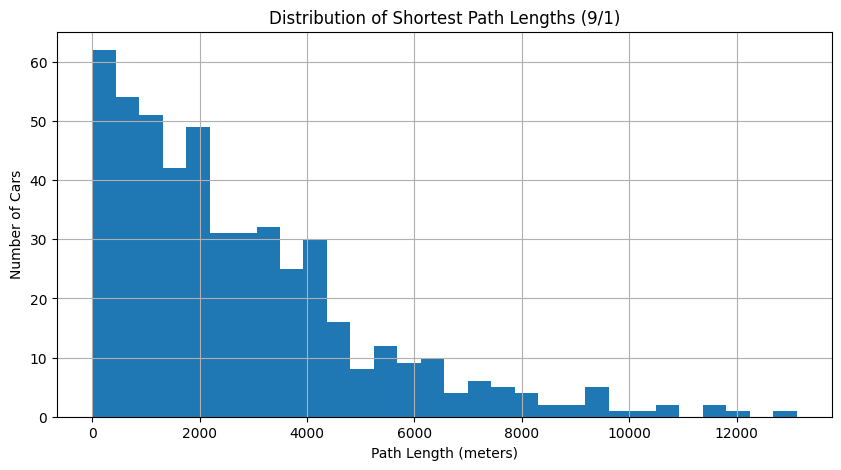

In [17]:
import matplotlib.pyplot as plt

# Remove cars with path_length = None
valid_paths = df_paths[df_paths['path_length'].notna()]

plt.figure(figsize=(10, 5))
plt.hist(valid_paths['path_length'], bins=30)
plt.title("Distribution of Shortest Path Lengths (9/1)")
plt.xlabel("Path Length (meters)")
plt.ylabel("Number of Cars")
plt.grid(True)
plt.show()

In [19]:
avg_length_by_start = valid_paths.groupby('start_node')['path_length'].mean().reset_index()

# Show as table
display(avg_length_by_start.sort_values(by='path_length', ascending=False).head(10))


,start_node,path_length
69,5113,12149.581923
80,8448,11591.533241
84,9035,10239.613339
73,5140,9414.389085
57,4943,8445.807564
59,4947,8062.257663
85,9042,7726.178765
54,4929,7589.044422
79,8441,7397.744720
41,4802,7218.078404
